In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [2]:
N = 30
GPS = ['tnfa', 'tgfb']
GP_UPPER = ['TNFa', 'TGFb']
RUNS_TO_USE = [0, 1, 2] #, 3, 4]  

SPECTRA_FNS = [
    f'tripso_reproducibility/05_gpfinder/spectra_repeat/recover_{gp.lower()}/seed_{i}/{gp}_gene_weights.csv'
    for gp in GP_UPPER
    for i in RUNS_TO_USE
]
GPFINDER_FNS = [
    f'tripso_reproducibility/05_gpfinder/benchmark_retrain/{gp}/output_gpfinder_{i}/attention_simple/genes_ranked_by_attention.csv'
    for gp in GPS
    for i in RUNS_TO_USE
]

# GROUND_TRUTH_PATH = '/lustre/scratch126/cellgen/lotfollahi/cs60/proj_gpfinder/benchmark/gpdb_perturbseq_exclusive.csv'
# GROUND_TRUTH_PATH = '/lustre/scratch126/cellgen/lotfollahi/cs60/proj_gpfinder/benchmark/gpdb_perturbseq_extended.csv'
GROUND_TRUTH_PATH = '../benchmark_repeat/pathways_extended.csv'

In [3]:
spectra_genes = [pd.read_csv(fn)['gene'].tolist() for fn in SPECTRA_FNS]
gpfinder_genes = [pd.read_csv(fn)['gene'].tolist() for fn in GPFINDER_FNS]
gt_genes = pd.read_csv(GROUND_TRUTH_PATH)

In [4]:
for i in range(len(spectra_genes)):
    print(len(spectra_genes[i]))

1861
1861
1861
1861
1861
1861


In [5]:
# Calculate Spectra (flexible number of runs)
num_runs_per_gp = len(RUNS_TO_USE)
total_runs = len(GPS) * num_runs_per_gp
spectra_all = np.zeros((total_runs, N))
num_true_genes = {}
total_num_genes = {}

random_chance = {}


for gp_i, gp in enumerate(GPS):
    gp_name = 'TNFa' if gp == 'tnfa' else 'TGFb'
    gt_gp_genes = set(gt_genes[gp_name].dropna().tolist())
    num_true_genes[gp] = len(gt_gp_genes)
    
    for run_idx, i in enumerate(RUNS_TO_USE):
        i_ = run_idx + (num_runs_per_gp * gp_i)
        genes = spectra_genes[i_]
        
        total_num_genes[gp] = len(genes)
        
        for n in range(1, N+1):
            spectra_all[i_, n-1] = len(set(genes[:n]).intersection(gt_gp_genes))
            
    print(f'Total number ground truth genes in {gp}', len(gt_gp_genes))
    print(f'Total number input genes {gp}', len(genes))
    random_chance[gp] = len(gt_gp_genes)/len(genes)
    print('')
            
spectra_results = {
    'mean': {
        'all': spectra_all.mean(0),
        'tnfa': spectra_all[:num_runs_per_gp].mean(0),
        'tgfb': spectra_all[num_runs_per_gp:].mean(0),
    },
    'std': {
        'all': spectra_all.std(0),
        'tnfa': spectra_all[:num_runs_per_gp].std(0),
        'tgfb': spectra_all[num_runs_per_gp:].std(0),
    },
}

Total number ground truth genes in tnfa 561
Total number input genes tnfa 1861

Total number ground truth genes in tgfb 408
Total number input genes tgfb 1861



In [6]:
# Calculate GPFinder (flexible number of runs)
num_runs_per_gp = len(RUNS_TO_USE)
total_runs = len(GPS) * num_runs_per_gp
gpfinder_all = np.zeros((total_runs, N))

for gp_i, gp in enumerate(GPS):
    gp_name = 'TNFa' if gp == 'tnfa' else 'TGFb'
    gt_gp_genes = set(gt_genes[gp_name].dropna().tolist())
    for run_idx, i in enumerate(RUNS_TO_USE):
        i_ = run_idx + (num_runs_per_gp * gp_i)
        genes = gpfinder_genes[i_]
        for n in range(1, N+1):
            gpfinder_all[i_, n-1] = len(set(genes[:n]).intersection(gt_gp_genes))

gpfinder_results = {
    'mean': {
        'all': gpfinder_all.mean(0),
        'tnfa': gpfinder_all[:num_runs_per_gp].mean(0),
        'tgfb': gpfinder_all[num_runs_per_gp:].mean(0),
    },
    'std': {
        'all': gpfinder_all.std(0),
        'tnfa': gpfinder_all[:num_runs_per_gp].std(0),
        'tgfb': gpfinder_all[num_runs_per_gp:].std(0),
    },
}

### 1. Benchmark, all (averaged across TNFa & TGFb)

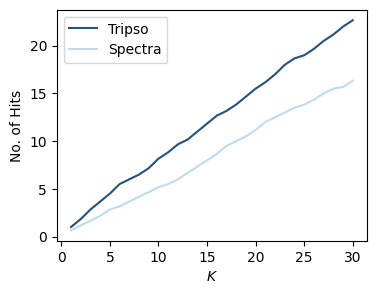

In [7]:
gp = 'all'

fig = plt.figure(figsize=(4, 3))
plt.plot(np.arange(1, N+1), gpfinder_results['mean'][gp], color='#25527c', label='Tripso')
plt.plot(np.arange(1, N+1), spectra_results['mean'][gp], color= '#c1dbed', label='Spectra')

# plt.plot(np.arange(1, N+1), np.arange(1, N+1),  '--', label='Perfect', color='thistle')
# bsl = (random_chance['tnfa'] + random_chance['tgfb'])/2
# plt.plot(np.arange(1, N+1), np.arange(1, N+1) * bsl, 'g--', label='Random chance', color = 'darkgrey')

# # plt.fill_between(np.arange(1, N+1), 
#                  gpfinder_results['mean'][gp] - gpfinder_results['std'][gp], 
#                  gpfinder_results['mean'][gp] + gpfinder_results['std'][gp], 
#                  color='#25527c', 
#                  alpha=0.2)

# plt.fill_between(np.arange(1, N+1), 
#                  spectra_results['mean'][gp] - spectra_results['std'][gp], 
#                  spectra_results['mean'][gp] + spectra_results['std'][gp], 
#                  color='#c1dbed', alpha=0.3)

plt.legend()
plt.xlabel(r'$K$')
plt.ylabel('No. of Hits')
plt.savefig('tripso_vs_spectra_updated.pdf', bbox_inches='tight')
plt.show()

### 2. Benchmark for TNFa

/tmp/ipykernel_2089497/3155121978.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(np.arange(1, N+1), np.arange(1, N+1) * baseline_true/baseline_poss, 'g--', label='Random chance', color = 'darkgrey')


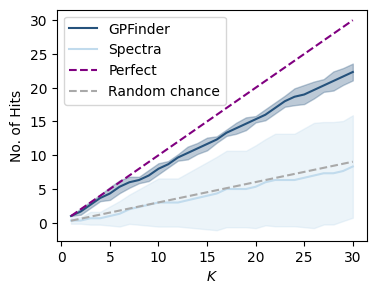

In [8]:
gp = 'tnfa'

fig = plt.figure(figsize=(4, 3))
plt.plot(np.arange(1, N+1), gpfinder_results['mean'][gp], color='#25527c', label='GPFinder')
plt.plot(np.arange(1, N+1), spectra_results['mean'][gp], color='#c1dbed', label='Spectra')

plt.plot(np.arange(1, N+1), np.arange(1, N+1),  '--', label='Perfect', color='purple')
baseline_true = num_true_genes[gp]
baseline_poss = total_num_genes[gp]
plt.plot(np.arange(1, N+1), np.arange(1, N+1) * baseline_true/baseline_poss, 'g--', label='Random chance', color = 'darkgrey')

plt.fill_between(np.arange(1, N+1), gpfinder_results['mean'][gp] - gpfinder_results['std'][gp], gpfinder_results['mean'][gp] + gpfinder_results['std'][gp], color='#25527c', alpha=0.3)
plt.fill_between(np.arange(1, N+1), spectra_results['mean'][gp] - spectra_results['std'][gp], spectra_results['mean'][gp] + spectra_results['std'][gp], color='#c1dbed', alpha=0.3)
plt.legend()
plt.xlabel(r'$K$')
plt.ylabel('No. of Hits')
# plt.savefig(f'{FOLDER_FIGS}/benchmark_{gp}.pdf', bbox_inches='tight')
plt.show()

### 3. Benchmark for TGFb

/tmp/ipykernel_2089497/1694783153.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(np.arange(1, N+1), np.arange(1, N+1) * baseline_true/baseline_poss, 'g--', label='Random chance', color = 'darkgrey')


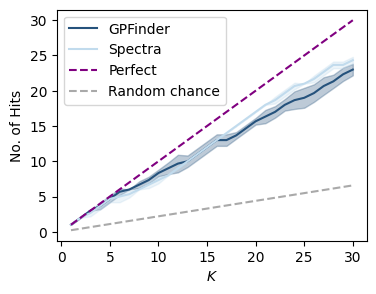

In [9]:
gp = 'tgfb'

fig = plt.figure(figsize=(4, 3))
plt.plot(np.arange(1, N+1), gpfinder_results['mean'][gp], color='#25527c', label='GPFinder')
plt.plot(np.arange(1, N+1), spectra_results['mean'][gp], color='#c1dbed', label='Spectra')

plt.plot(np.arange(1, N+1), np.arange(1, N+1),  '--', label='Perfect', color='purple')
baseline_true = num_true_genes[gp]
baseline_poss = total_num_genes[gp]
plt.plot(np.arange(1, N+1), np.arange(1, N+1) * baseline_true/baseline_poss, 'g--', label='Random chance', color = 'darkgrey')

plt.fill_between(np.arange(1, N+1), gpfinder_results['mean'][gp] - gpfinder_results['std'][gp], gpfinder_results['mean'][gp] + gpfinder_results['std'][gp], color='#25527c', alpha=0.3)
plt.fill_between(np.arange(1, N+1), spectra_results['mean'][gp] - spectra_results['std'][gp], spectra_results['mean'][gp] + spectra_results['std'][gp], color='#c1dbed', alpha=0.3)
plt.legend()
plt.xlabel(r'$K$')
plt.ylabel('No. of Hits')
# plt.savefig(f'{FOLDER_FIGS}/benchmark_{gp}.pdf', bbox_inches='tight')
plt.show()

### Create Summary Table for Gene Recovery

In [10]:
# Create summary table with results for topN = [1, 10, 20, 50]
topN_values = [1, 5, 10, 20, 30]
tasks = ['tnfa', 'tgfb']
models = ['tripso', 'spectra']

# Map task names
task_name_map = {'tnfa': 'TNFa', 'tgfb': 'TGFb'}

# Create list to store rows
rows = []

for task in tasks:
    task_display = task_name_map[task]
    
    for model in models:
        # Get the appropriate results dictionary
        if model == 'tripso':
            results = gpfinder_results
        else:  # spectra
            results = spectra_results
        
        # Extract mean and std for each topN value
        for topN in topN_values:
            # Array indices are 0-based, so topN=1 is index 0, topN=10 is index 9, etc.
            idx = topN - 1
            
            mean_correct = results['mean'][task][idx]
            std_correct = results['std'][task][idx]
            
            rows.append({
                'task': task_display,
                'model': model,
                'topN': topN,
                'mean_correct': mean_correct,
                'std': std_correct
            })

# Create DataFrame
summary_df = pd.DataFrame(rows)

# Display the table
print(summary_df.to_string(index=False))

# Save to CSV
output_path = 'gpfinder_gene_recovery_suppl_update_spectra.csv'
summary_df.to_csv(output_path, index=False)
print(f"\nTable saved to: {output_path}")

task   model  topN  mean_correct      std
TNFa  tripso     1      1.000000 0.000000
TNFa  tripso     5      4.333333 0.942809
TNFa  tripso    10      8.000000 0.816497
TNFa  tripso    20     15.333333 0.471405
TNFa  tripso    30     22.333333 1.247219
TNFa spectra     1      0.333333 0.471405
TNFa spectra     5      1.000000 1.414214
TNFa spectra    10      3.000000 3.559026
TNFa spectra    20      5.333333 6.128259
TNFa spectra    30      8.333333 7.586538
TGFb  tripso     1      1.000000 0.000000
TGFb  tripso     5      4.666667 0.471405
TGFb  tripso    10      8.333333 0.471405
TGFb  tripso    20     15.666667 0.471405
TGFb  tripso    30     23.000000 0.816497
TGFb spectra     1      1.000000 0.000000
TGFb spectra     5      4.666667 0.471405
TGFb spectra    10      7.333333 0.471405
TGFb spectra    20     17.000000 0.000000
TGFb spectra    30     24.333333 0.471405

Table saved to: gpfinder_gene_recovery_suppl_update_spectra.csv


### Bar Plot: Gene Recovery at Different TopN Values

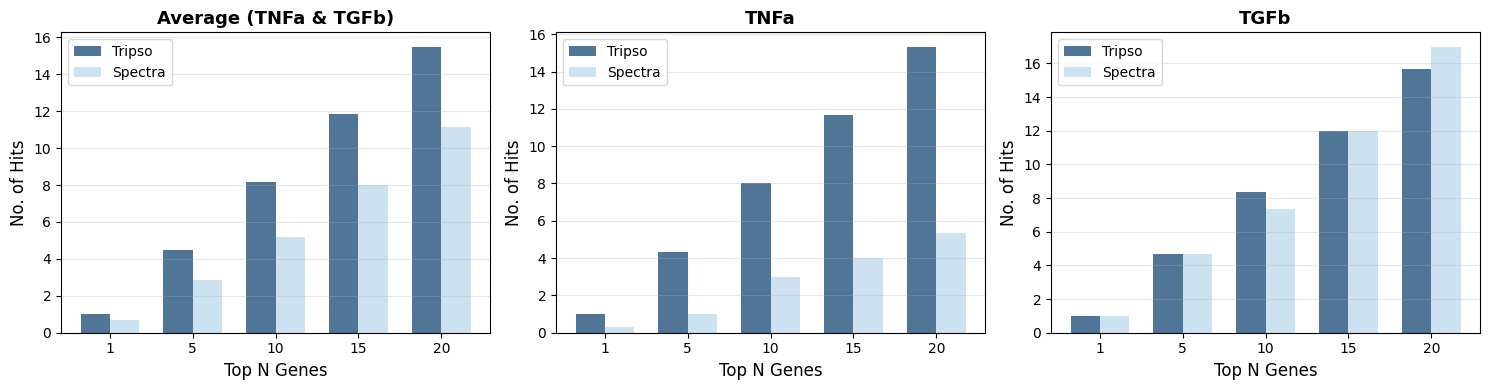

In [11]:
# Create bar plot comparing Tripso and Spectra at topN = [1, 5, 10, 15]
topN_values = [1, 5, 10, 15, 20]
topN_indices = [n - 1 for n in topN_values]  # Convert to 0-based indices

# Tasks to plot
tasks = ['all', 'tnfa', 'tgfb']
task_titles = ['Average (TNFa & TGFb)', 'TNFa', 'TGFb']

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar width and positions
bar_width = 0.35
x_pos = np.arange(len(topN_values))

# Colors for each model
tripso_color = '#25527c'
spectra_color = '#c1dbed'

for ax, task, title in zip(axes, tasks, task_titles):
    # Extract mean values for this task
    tripso_means = [gpfinder_results['mean'][task][idx] for idx in topN_indices]
    spectra_means = [spectra_results['mean'][task][idx] for idx in topN_indices]
    
    # Create bars
    ax.bar(x_pos - bar_width/2, tripso_means, bar_width, 
           label='Tripso', color=tripso_color, alpha=0.8)
    ax.bar(x_pos + bar_width/2, spectra_means, bar_width, 
           label='Spectra', color=spectra_color, alpha=0.8)
    
    # Customize subplot
    ax.set_xlabel('Top N Genes', fontsize=12)
    ax.set_ylabel('No. of Hits', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(topN_values)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('gene_recovery_barplot.pdf', bbox_inches='tight')
plt.show()